In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score,
    precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#Reading the CSV file

df = pd.read_csv('/content/prostate_cancer_prediction.csv')

df.head(3)

,Patient_ID,Age,Family_History,Race_African_Ancestry,PSA_Level,DRE_Result,Biopsy_Result,Difficulty_Urinating,Weak_Urine_Flow,Blood_in_Urine,...,Alcohol_Consumption,Hypertension,Diabetes,Cholesterol_Level,Screening_Age,Follow_Up_Required,Prostate_Volume,Genetic_Risk_Factors,Previous_Cancer_History,Early_Detection
0,1,78,No,Yes,5.07,Normal,Benign,No,No,No,...,Moderate,No,No,Normal,45,No,46.0,No,No,Yes
1,2,68,No,Yes,10.24,Normal,Benign,Yes,No,No,...,Low,No,No,High,65,No,78.2,No,No,Yes
2,3,54,No,No,13.79,Normal,Benign,No,No,No,...,Low,No,No,Normal,61,No,21.1,No,No,Yes


In [ ]:
#Dropping the ID Coloumn for the sake of Dimensionality reduction and it serve no purpose in either case
df.drop(columns=["Patient_ID"],inplace=True)

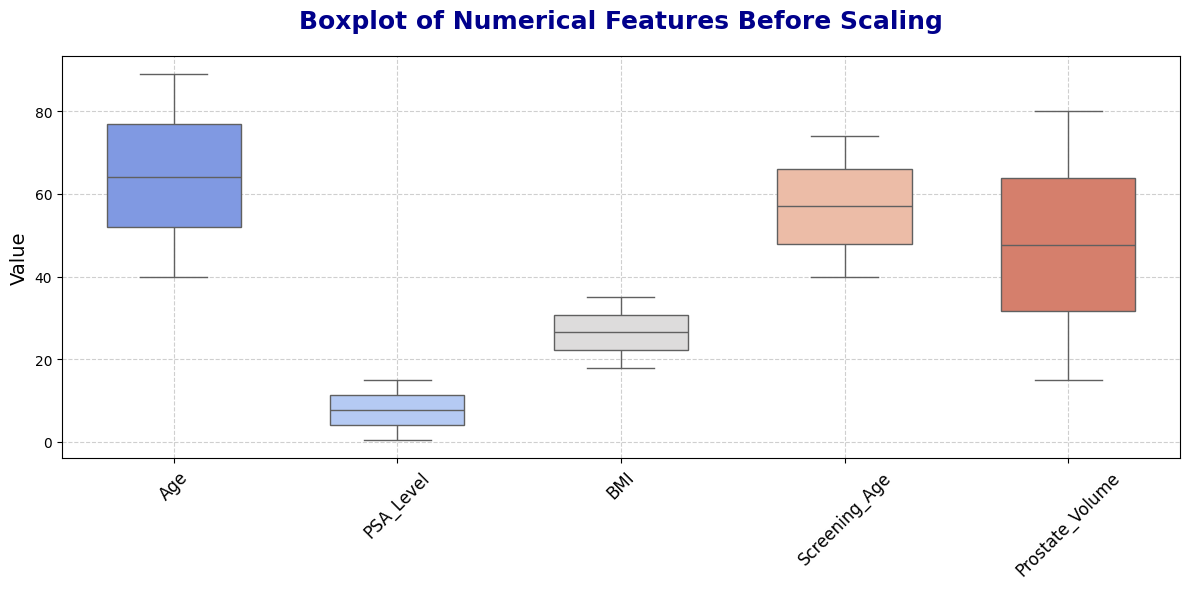

        Age  Family_History  Race_African_Ancestry  PSA_Level  DRE_Result  \
0  0.939988               0                      1  -0.642309           1   
1  0.245761               0                      1   0.596033           1   
2 -0.726158               0                      0   1.446345           1   
3  1.217679               0                      0   0.066684           0   
4 -1.212117               1                      0  -1.403997           1   

   Biopsy_Result  Difficulty_Urinating  Weak_Urine_Flow  Blood_in_Urine  \
0              0                     0                0               0   
1              0                     1                0               0   
2              0                     0                0               0   
3              0                     0                0               0   
4              1                     1                1               0   

   Pelvic_Pain  ...  Smoking_History  Alcohol_Consumption  Hypertension  \
0          

In [ ]:


# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Separate the target variable before encoding
y = df['Early_Detection']  # Store target before encoding
x = df.drop(columns=['Early_Detection'])  # Drop target column

# Saving original numerical data for boxplot comparison
original_numerical = x[numerical_cols].copy()

# Encoding categorical columns (except Early_Detection) using LabelEncoder
label_enc = LabelEncoder()
for col in categorical_cols:
    if col != 'Early_Detection':  # Avoid encoding target variable here
        x[col] = label_enc.fit_transform(x[col])

# Apply Standard Scaling only to numerical features
scaler = StandardScaler()
x[numerical_cols] = scaler.fit_transform(x[numerical_cols])

# Encode the target variable separately
y = label_enc.fit_transform(y)  # Convert 'Yes'/'No' to 1/0

# Modernized Boxplot for BEFORE Scaling
plt.figure(figsize=(12, 6))
sns.boxplot(data=original_numerical, palette="coolwarm", width=0.6)

plt.title('Boxplot of Numerical Features Before Scaling', fontsize=18, weight='bold', color='darkblue', pad=20)
plt.xticks(range(len(numerical_cols)), numerical_cols, rotation=45, fontsize=12)
plt.ylabel('Value', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(x.head())
print(y[:5])


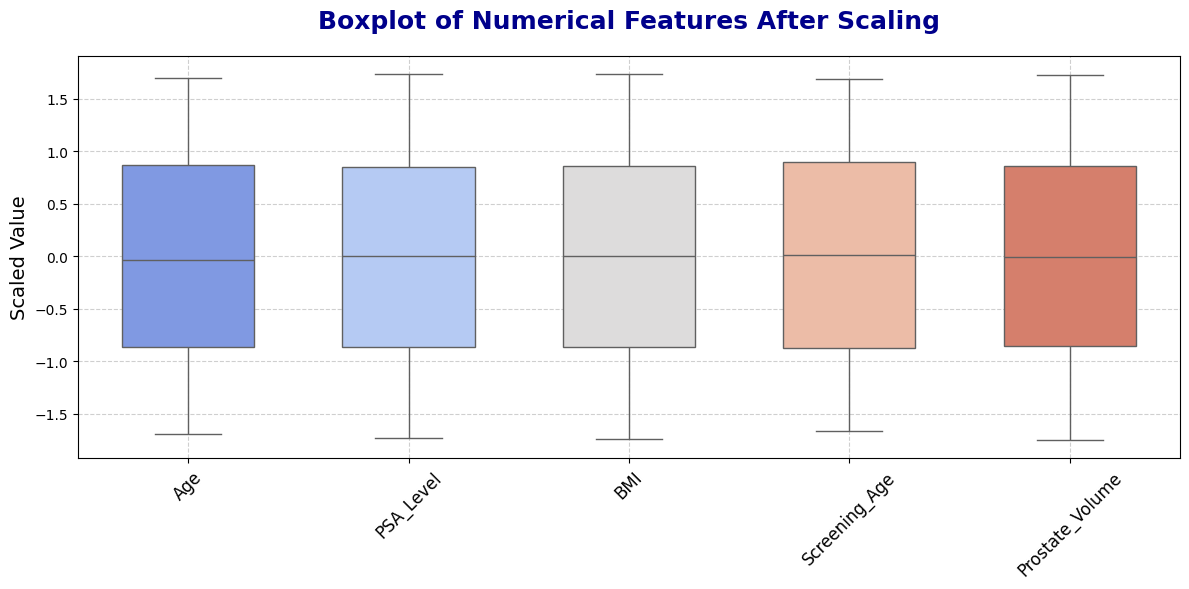

In [ ]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=x[numerical_cols], palette="coolwarm", width=0.6)

plt.title('Boxplot of Numerical Features After Scaling', fontsize=18, weight='bold', color='darkblue', pad=20)
plt.xticks(range(len(numerical_cols)), numerical_cols, rotation=45, fontsize=12)
plt.ylabel('Scaled Value', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


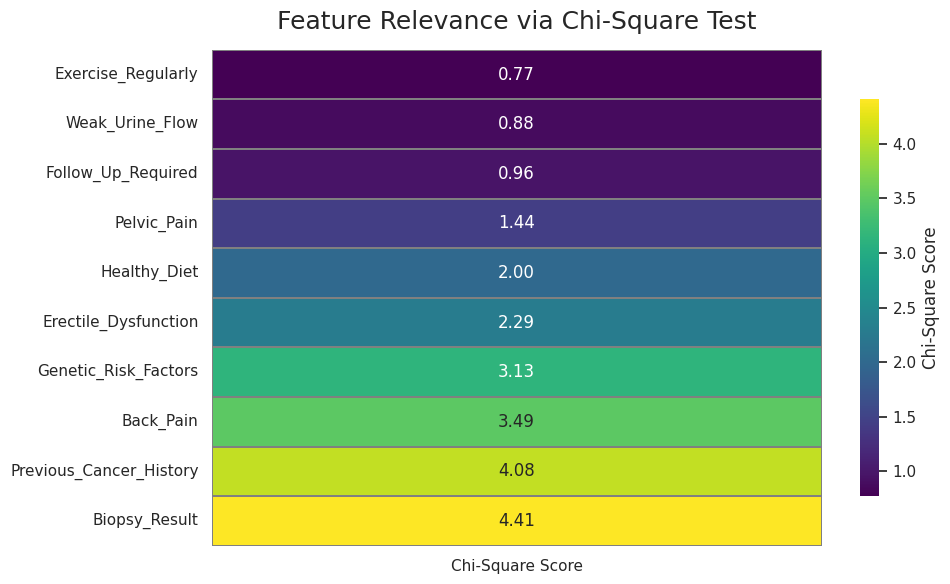

In [ ]:


X_scaled = MinMaxScaler().fit_transform(x)  # X is our encoded feature matrix
chi2_scores, _ = chi2(X_scaled, y)  # y is our binary target
chi2_series = pd.Series(chi2_scores, index=x.columns).sort_values(ascending=False).head(10)

sns.set_theme(style="white")

chi2_heatmap_data = chi2_series.sort_values(ascending=True).to_frame(name='Chi-Square Score')

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    chi2_heatmap_data,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=0.2,
    cbar_kws={"shrink": 0.8, 'label': 'Chi-Square Score'},
    linecolor='gray'
)
ze labels
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("Feature Relevance via Chi-Square Test", fontsize=18, pad=15)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()


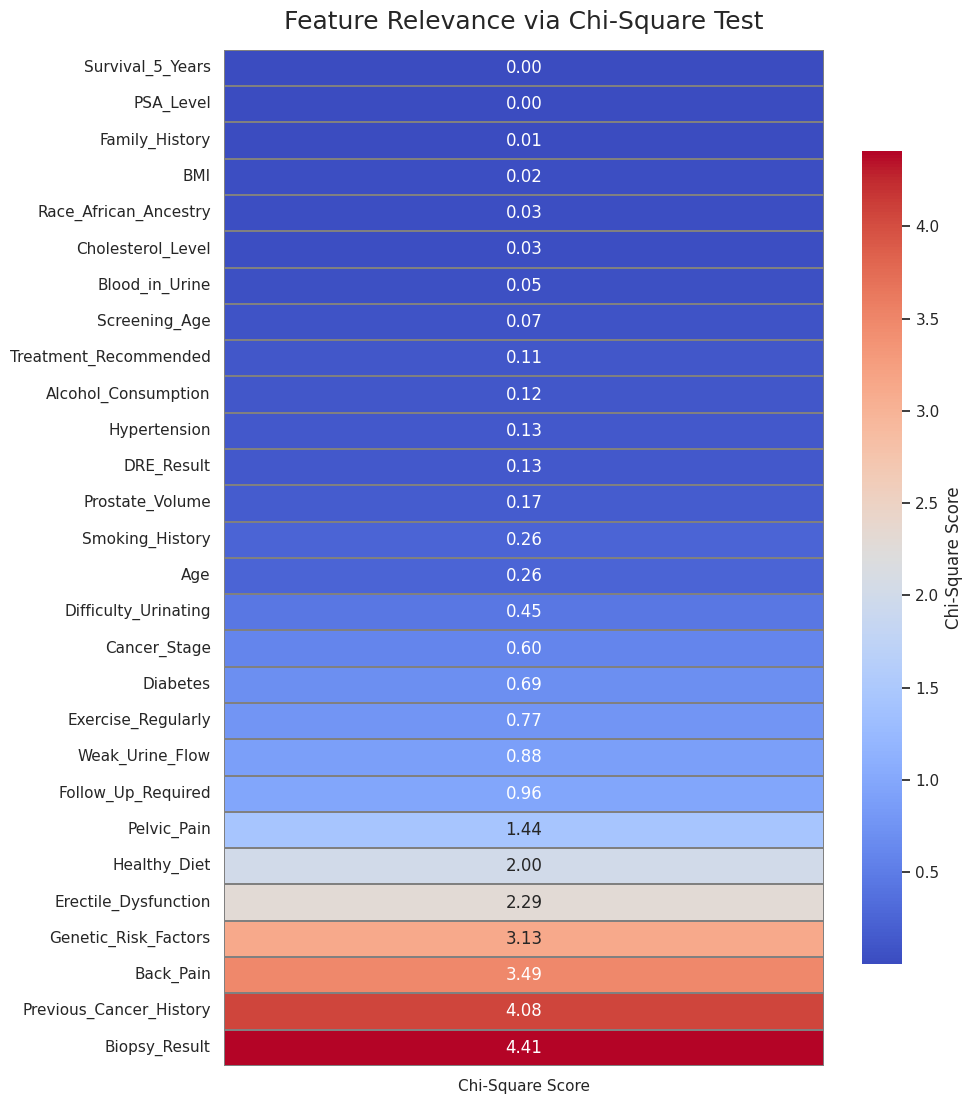

In [ ]:

X_scaled = MinMaxScaler().fit_transform(x)  # Use our full feature set
chi2_scores, _ = chi2(X_scaled, y)          # y = target

chi2_series = pd.Series(chi2_scores, index=x.columns).sort_values(ascending=False)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

chi2_heatmap_data = chi2_series.sort_values(ascending=True).to_frame(name='Chi-Square Score')

plt.figure(figsize=(10, max(6, 0.4 * len(chi2_heatmap_data))))
ax = sns.heatmap(
    chi2_heatmap_data,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.2,
    cbar_kws={"shrink": 0.8, 'label': 'Chi-Square Score'},
    linecolor='gray'
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.title("Feature Relevance via Chi-Square Test", fontsize=18, pad=15)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=19, train_size=0.80)

In [ ]:
# Handling class imbalance using SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)


<ipython-input-15-c0285f0e0a47>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(Counter(y_train).keys()), y=list(Counter(y_train).values()), palette='coolwarm')


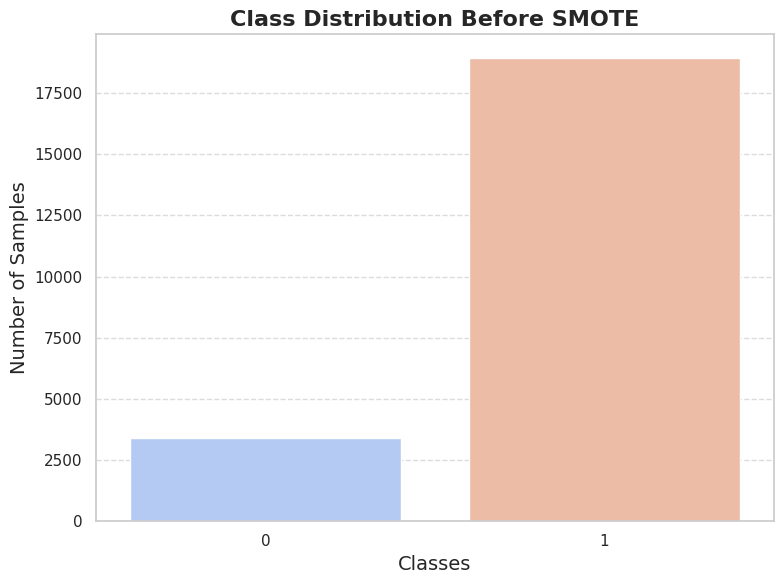

In [ ]:
from collections import Counter

sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(x=list(Counter(y_train).keys()), y=list(Counter(y_train).values()), palette='coolwarm')

plt.title("Class Distribution Before SMOTE", fontsize=16, weight='bold')
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Number of Samples", fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("before_smote_modern.png", dpi=300)
plt.show()



<ipython-input-16-ca3551078245>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(Counter(y_train_resampled).keys()), y=list(Counter(y_train_resampled).values()), palette='viridis')


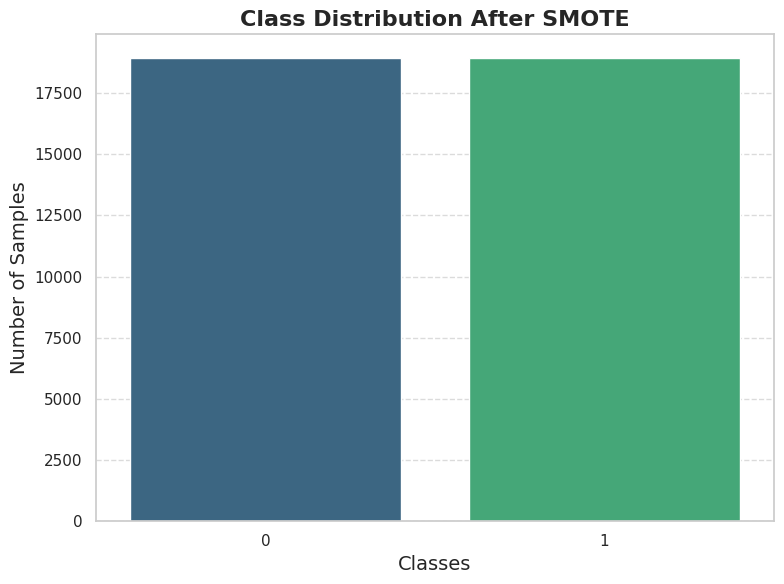

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(x=list(Counter(y_train_resampled).keys()), y=list(Counter(y_train_resampled).values()), palette='viridis')

plt.title("Class Distribution After SMOTE", fontsize=16, weight='bold')
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Number of Samples", fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("after_smote_modern.png", dpi=300)
plt.show()

# Gradient Booster

Confusion Matrix:
 [[  13  786]
 [  95 4695]]
Training Accuracy: 0.9549
Testing Accuracy: 0.8424
Sensitivity (Recall): 0.9802
Specificity: 0.0163
Balanced Error Rate: 0.5018
F1 Score: 0.9142
MCC: -0.0091
Kappa: -0.0056
ROC-AUC Score: 0.5214
Precision-Recall AUC: 0.8632


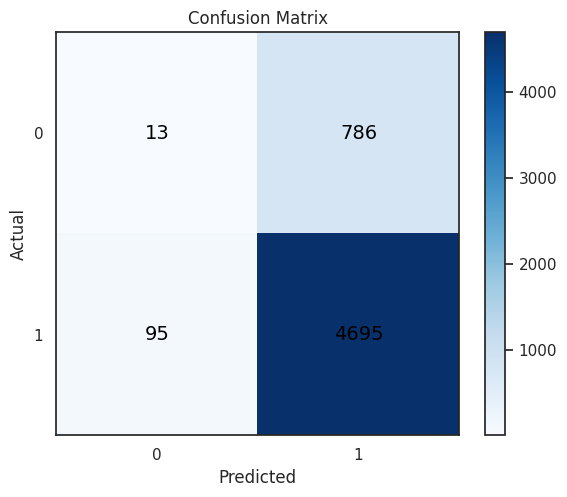

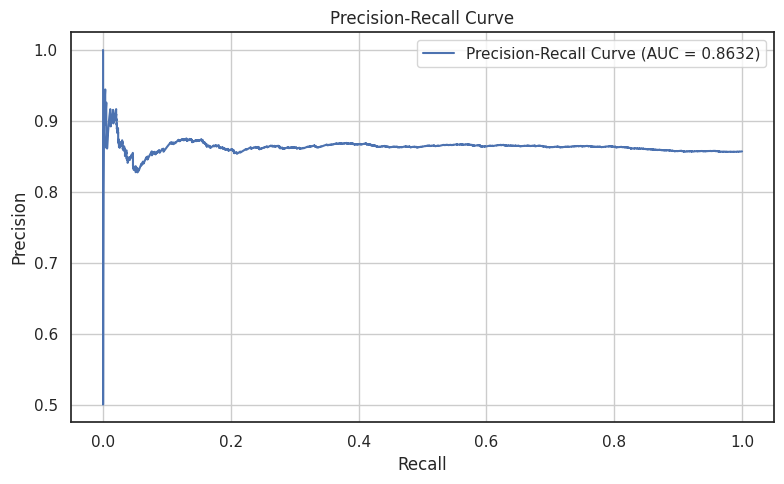

In [ ]:

# Fixed parameters
params = {
    'n_estimators': 250,
    'learning_rate': 0.1,
    'max_depth': 7,
    'subsample': 1.0,
    'min_samples_split': 7
}

# Train model
model = GradientBoostingClassifier(**params, random_state=42)
model.fit(x_train_resampled, y_train_resampled)

# Training accuracy
y_train_pred = model.predict(x_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# Testing predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Confusion matrix and AUC
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final  # Sensitivity
spe = tn / (tn + fp)  # Specificity
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:


# Custom PR AUC scorer
def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

# Gradient Boosting model
model = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.1,
    max_depth=7,
    subsample=1.0,
    min_samples_split=7,
    random_state=42
)

# Pipeline with SMOTE
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', model)
])

# Custom scoring dictionary
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)

# Print cross-validation results
print("\n📊 10-Fold CV Results with SMOTE (Gradient Boosting):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")



📊 10-Fold CV Results with SMOTE (Gradient Boosting):
ACCURACY: 0.8357 ± 0.0035
PRECISION: 0.8489 ± 0.0007
RECALL: 0.9813 ± 0.0041
F1: 0.9103 ± 0.0021
ROC_AUC: 0.4958 ± 0.0125
PR_AUC: 0.8482 ± 0.0059
BER: 0.5033 ± 0.0028


# XGB Classifier

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:24:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Confusion Matrix:
 [[  71  728]
 [ 363 4427]]
Training Accuracy: 0.9133
Testing Accuracy: 0.8048
Sensitivity (Recall): 0.9242
Specificity: 0.0889
Balanced Error Rate: 0.4935
F1 Score: 0.8903
MCC: 0.0171
Kappa: 0.0162
ROC-AUC Score: 0.5121
Precision-Recall AUC: 0.8582


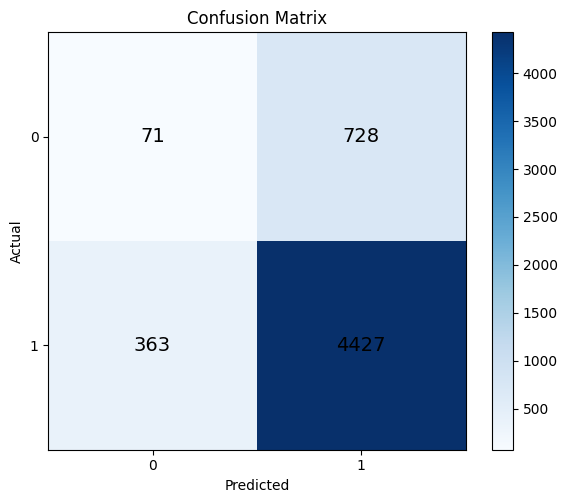

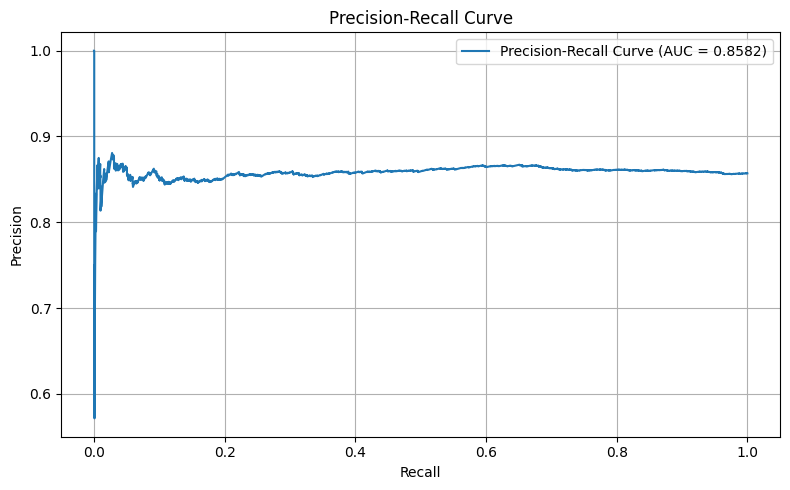

In [ ]:
# Defining parameters
params = {
    'n_estimators': 200,
    'max_depth': 7,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'use_label_encoder': False,
    'eval_metric': 'logloss'
}

# Training XGBoost model
model = XGBClassifier(**params, random_state=42)
model.fit(x_train_resampled, y_train_resampled)

# Training accuracy
y_train_pred = model.predict(x_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# Test predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Confusion matrix and AUC
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final  # Sensitivity
spe = tn / (tn + fp)  # Specificity
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10 Fold Cross Validations

In [ ]:


# Custom PR AUC scorer
def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Pipeline with SMOTE
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', xgb_model)
])

# Scoring dictionary (custom callables)
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# CV setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)

# Print results
print("\n📊 10-Fold CV Results with SMOTE (XGBoost):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:52:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:52:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:52:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:52:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:53:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


📊 10-Fold CV Results with SMOTE (XGBoost):
ACCURACY: 0.7972 ± 0.0057
PRECISION: 0.8498 ± 0.0017
RECALL: 0.9248 ± 0.0075
F1: 0.8857 ± 0.0036
ROC_AUC: 0.4916 ± 0.0113
PR_AUC: 0.8474 ± 0.0059
BER: 0.5001 ± 0.0063


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Info] Number of positive: 18957, number of negative: 18957
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 37914, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGB

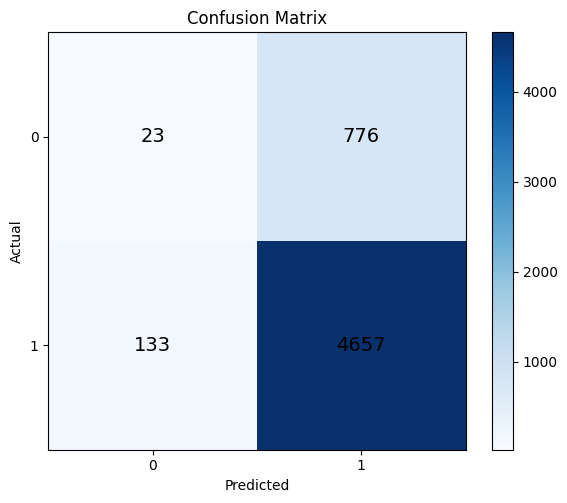

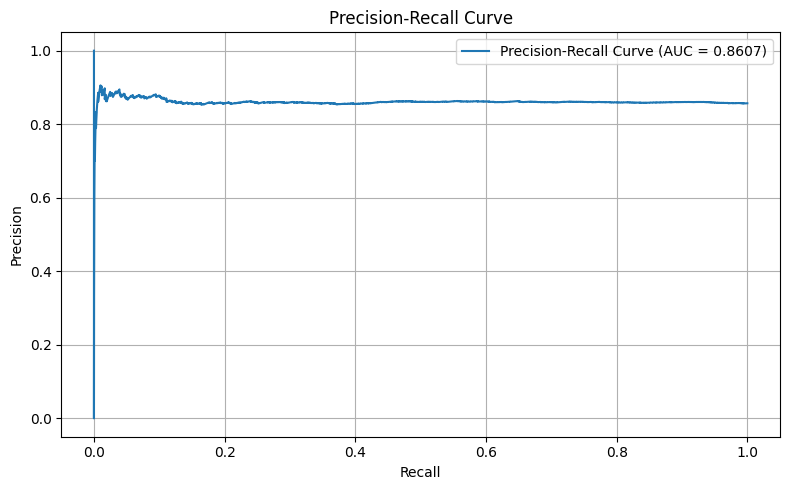

In [ ]:

# Define LightGBM parameters
params = {
    'n_estimators': 200,
    'learning_rate': 0.15,
    'max_depth': 7,
    'min_child_samples': 7,
    'max_bin': 100,
    'feature_fraction': 0.7,
    'min_data_in_leaf': 20
}

# Train LightGBM model
model = LGBMClassifier(**params, random_state=42)
model.fit(x_train_resampled, y_train_resampled)

# Training accuracy
y_train_pred = model.predict(x_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# Predictions on test set
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Evaluation metrics
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final  # Sensitivity
spe = tn / (tn + fp)  # Specificity
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print all metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10 Fold Cross Validation with LGM

In [ ]:

def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

# LightGBM model
lgm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.15,
    max_depth=7,
    min_child_samples=7,
    max_bin=100,
    feature_fraction=0.7,
    min_data_in_leaf=20,
    random_state=42
)

# Pipeline with SMOTE
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', lgm_model)
])

# Custom scoring dictionary
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# Stratified 10-Fold CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)
# print average metrics
print("\n📊 10-Fold CV Results with SMOTE (LightGBM):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Info] Number of positive: 21372, number of negative: 21372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 42744, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGB

Confusion Matrix:
 [[ 333  466]
 [1921 2869]]
Training Accuracy: 0.6855
Testing Accuracy: 0.5729
Sensitivity (Recall): 0.5990
Specificity: 0.4168
Balanced Error Rate: 0.4921
F1 Score: 0.7062
MCC: 0.0112
Kappa: 0.0089
ROC-AUC Score: 0.5068
Precision-Recall AUC: 0.8544


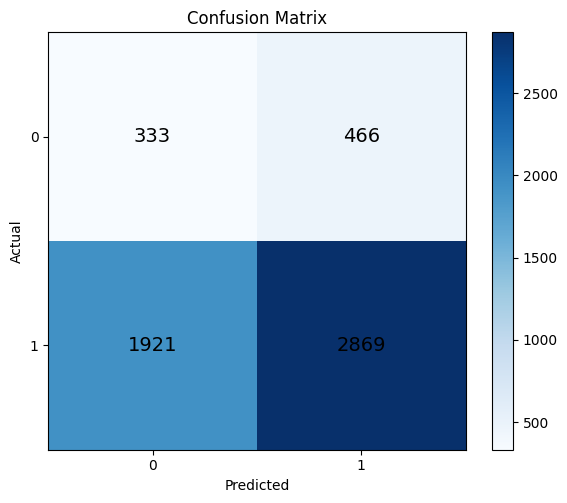

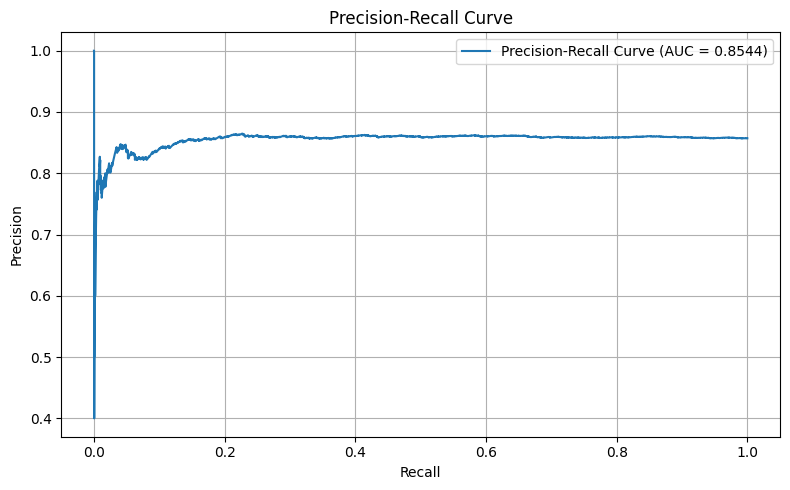

In [ ]:

params = {
    'var_smoothing': 1e-06
}

# Train Gaussian Naive Bayes model
model = GaussianNB(**params)
model.fit(x_train_resampled, y_train_resampled)

# raining accuracy
y_train_pred = model.predict(x_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# Test predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final
spe = tn / (tn + fp)
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# rint results
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Confusion matrix plot
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 10 Fold Cross Validation

In [ ]:

# Custom PR AUC scorer
def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

# Gaussian Naive Bayes model
gnb_model = GaussianNB(var_smoothing=1e-6)

# Pipeline with SMOTE
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', gnb_model)
])

# Custom scoring dictionary
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# Stratified 10-Fold CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)

# Print average metrics
print("\n📊 10-Fold CV Results with SMOTE (GaussianNB):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")



📊 10-Fold CV Results with SMOTE (GaussianNB):
ACCURACY: 0.5657 ± 0.0068
PRECISION: 0.8508 ± 0.0040
RECALL: 0.5929 ± 0.0083
F1: 0.6988 ± 0.0061
ROC_AUC: 0.5007 ± 0.0097
PR_AUC: 0.8500 ± 0.0049
BER: 0.4976 ± 0.0093


Confusion Matrix:
 [[ 240  559]
 [1345 3445]]
Training Accuracy: 0.7715
Testing Accuracy: 0.6593
Sensitivity (Recall): 0.7192
Specificity: 0.3004
Balanced Error Rate: 0.4902
F1 Score: 0.7835
MCC: 0.0152
Kappa: 0.0139
ROC-AUC Score: 0.5081
Precision-Recall AUC: 0.8582


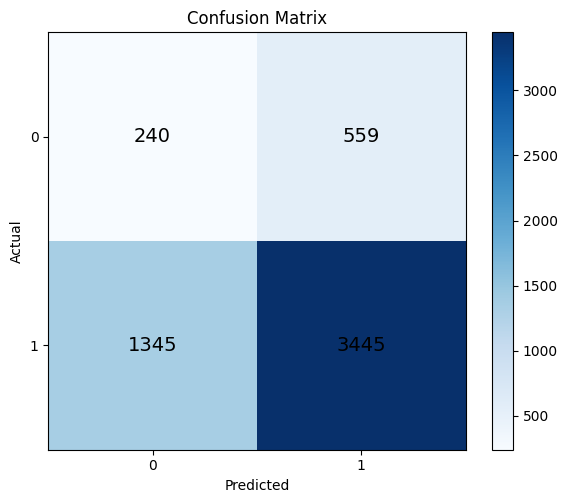

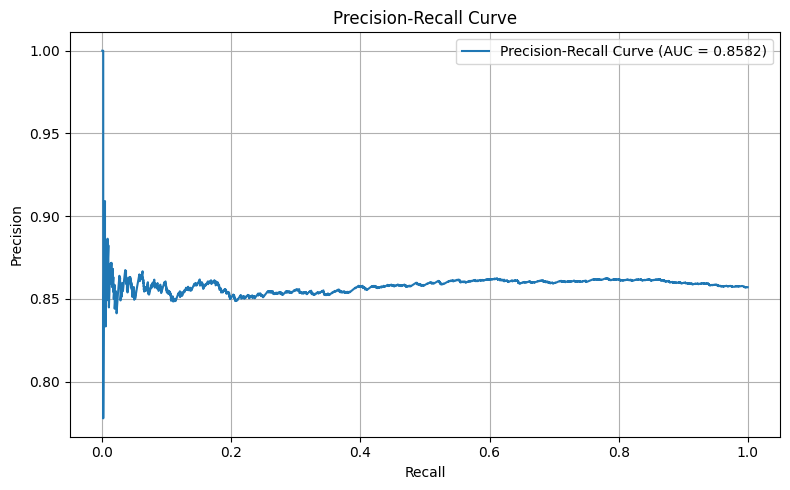

In [ ]:

params = {
    'n_estimators': 50,
    'max_depth': 10,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'random_state': 42
}

# Train Random Forest model
model = RandomForestClassifier(**params)
model.fit(x_train_resampled, y_train_resampled)

# Training accuracy
y_train_pred = model.predict(x_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# Test predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Confusion matrix and AUC
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final
spe = tn / (tn + fp)
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

#  Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 10 Fold Cross Validaiton

In [ ]:

# Custom PR AUC scorer
def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Pipeline with SMOTE
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', rf_model)
])

# Scoring dictionary
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# Stratified 10-Fold CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)

# Print average metrics
print("\n📊 10-Fold CV Results with SMOTE (Random Forest):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")



📊 10-Fold CV Results with SMOTE (Random Forest):
ACCURACY: 0.6553 ± 0.0054
PRECISION: 0.8503 ± 0.0027
RECALL: 0.7213 ± 0.0058
F1: 0.7805 ± 0.0040
ROC_AUC: 0.4975 ± 0.0078
PR_AUC: 0.8487 ± 0.0034
BER: 0.4985 ± 0.0074


Confusion Matrix:
 [[ 249  550]
 [1379 3411]]
Training Accuracy: 0.7384
Testing Accuracy: 0.6549
Sensitivity (Recall): 0.7121
Specificity: 0.3116
Balanced Error Rate: 0.4881
F1 Score: 0.7796
MCC: 0.0183
Kappa: 0.0166
ROC-AUC Score: 0.5056
Precision-Recall AUC: 0.8578


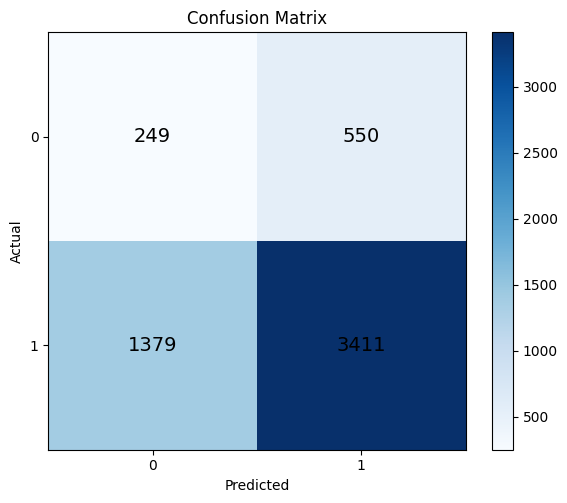

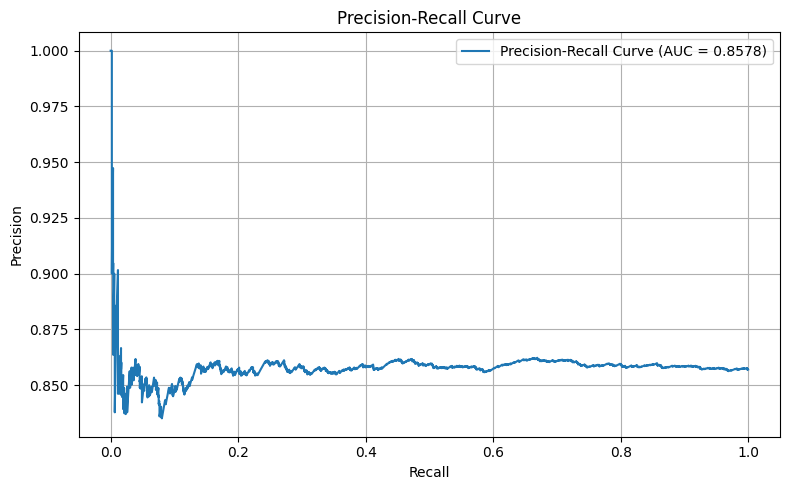

In [ ]:
# Defining SVM model with specific parameters
svm_model = SVC(C=10, kernel='rbf', gamma=0.01, class_weight='balanced', probability=False)

# Train the model
svm_model.fit(x_train_resampled, y_train_resampled)

# Training accuracy
y_train_pred = svm_model.predict(x_train_resampled)
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# Predictions
y_pred = svm_model.predict(x_test)
y_prob = svm_model.decision_function(x_test)  # For AUC and PR Curve

# Confusion matrix and AUC
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final  # Sensitivity
spe = tn / (tn + fp)  # Specificity
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 10 Fold Cross Validation

In [ ]:

# Custom PR AUC scorer
def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

# SVM model
svm_model = SVC(
    C=10,
    kernel='rbf',
    gamma=0.01,
    class_weight='balanced',
    probability=True,
    random_state=42
)

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', svm_model)
])

# Scoring dictionary
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# Stratified 10-Fold CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)

# Print average metrics
print("\n📊 10-Fold CV Results with SMOTE (SVM):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")



📊 10-Fold CV Results with SMOTE (SVM):
ACCURACY: 0.6481 ± 0.0079
PRECISION: 0.8494 ± 0.0031
RECALL: 0.7121 ± 0.0097
F1: 0.7747 ± 0.0062
ROC_AUC: 0.4905 ± 0.0086
PR_AUC: 0.8458 ± 0.0054
BER: 0.5010 ± 0.0084


In [ ]:
import os
import platform
import psutil
import shutil
import subprocess

# Operating System and Architecture
os_type = platform.system()
architecture = platform.architecture()[0]
cpu_arch = platform.machine()

# CPU Info
cpu_info = platform.processor()

# Total Memory
total_memory_gb = round(psutil.virtual_memory().total / (1024 ** 3), 2)

# Used Memory
used_memory_gb = round(psutil.virtual_memory().used / (1024 ** 3), 2)

# Disk Info
total_disk_gb, used_disk_gb, _ = [round(x / (1024 ** 3), 2) for x in shutil.disk_usage("/")]

# Environment
env = "Google Colab" if "COLAB_GPU" in os.environ else "Local Machine / Other"

# Print Details
print("📊 System Parameter Details\n")
print(f"Operating System     : {os_type}")
print(f"Architecture         : {architecture}")
print(f"CPU Architecture     : {cpu_arch}")
print(f"Processor            : {cpu_info}")
print(f"Total RAM            : {total_memory_gb} GB")
print(f"Used RAM             : {used_memory_gb} GB")
print(f"Total Disk           : {total_disk_gb} GB")
print(f"Used Disk            : {used_disk_gb} GB")
print(f"Execution Environment: {env}")


📊 System Parameter Details

Operating System     : Linux
Architecture         : 64bit
CPU Architecture     : x86_64
Processor            : x86_64
Total RAM            : 12.67 GB
Used RAM             : 1.53 GB
Total Disk           : 112.64 GB
Used Disk            : 36.97 GB
Execution Environment: Google Colab


Confusion Matrix:
 [[ 429  370]
 [2472 2318]]
Training Accuracy: 0.7932
Test Accuracy: 0.4915
Sensitivity (Recall): 0.4839
Specificity: 0.5369
Balanced Error Rate: 0.4896
F1 Score: 0.6200
MCC: 0.0146
Kappa: 0.0099
ROC-AUC Score: 0.5151
Precision-Recall AUC: 0.8699


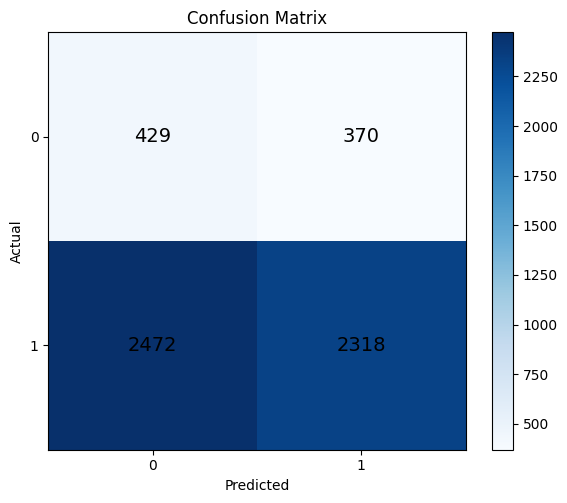

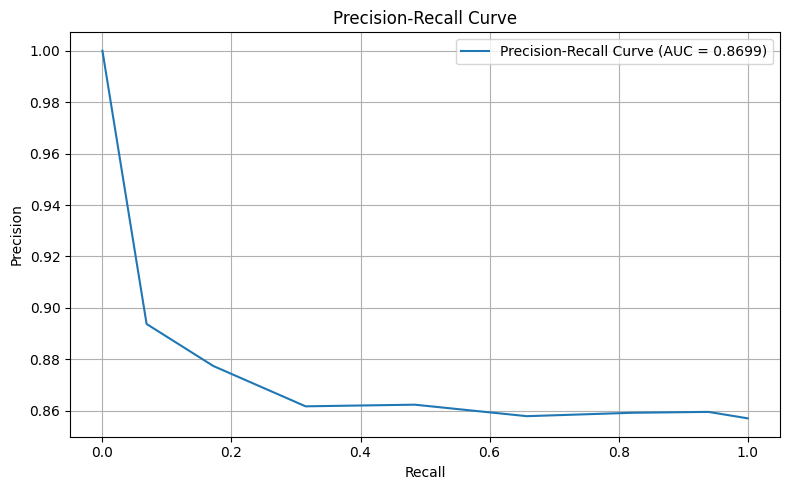

In [ ]:

model = KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='uniform')
model.fit(x_train_resampled, y_train_resampled)

# Predictions
y_pred_train = model.predict(x_train_resampled)
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

# Metrics
train_accuracy = accuracy_score(y_train_resampled, y_pred_train)
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
sen = recall_final
spe = tn / (tn + fp)
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 10 Fold Cross Validation with KNN

In [ ]:

# Custom PR AUC scorer
def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

# KNN model with specified parameters
knn_model = KNeighborsClassifier(
    metric='euclidean',
    n_neighbors=7,
    weights='uniform'
)

# SMOTE + KNN pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', knn_model)
])

# Scoring dictionary
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# 10-fold stratified CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)

# Print results
print("\n📊 10-Fold CV Results with SMOTE (KNN):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")



📊 10-Fold CV Results with SMOTE (KNN):
ACCURACY: 0.4881 ± 0.0066
PRECISION: 0.8505 ± 0.0057
RECALL: 0.4824 ± 0.0089
F1: 0.6156 ± 0.0073
ROC_AUC: 0.5013 ± 0.0131
PR_AUC: 0.8536 ± 0.0059
BER: 0.4988 ± 0.0106


# Tab Net

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

epoch 0  | loss: 0.79501 | train_auc: 0.63918 | valid_auc: 0.5021  |  0:00:06s
epoch 1  | loss: 0.65561 | train_auc: 0.69326 | valid_auc: 0.51055 |  0:00:10s
epoch 2  | loss: 0.62823 | train_auc: 0.72278 | valid_auc: 0.50949 |  0:00:13s
epoch 3  | loss: 0.61484 | train_auc: 0.74129 | valid_auc: 0.5124  |  0:00:16s
epoch 4  | loss: 0.60286 | train_auc: 0.75823 | valid_auc: 0.50923 |  0:00:19s
epoch 5  | loss: 0.5958  | train_auc: 0.76984 | valid_auc: 0.52105 |  0:00:22s
epoch 6  | loss: 0.58638 | train_auc: 0.77494 | valid_auc: 0.51498 |  0:00:26s
epoch 7  | loss: 0.57741 | train_auc: 0.78262 | valid_auc: 0.51655 |  0:00:29s
epoch 8  | loss: 0.57037 | train_auc: 0.78854 | valid_auc: 0.51148 |  0:00:32s
epoch 9  | loss: 0.56844 | train_auc: 0.79595 | valid_auc: 0.51444 |  0:00:35s
epoch 10 | loss: 0.56418 | train_auc: 0.79841 | valid_auc: 0.51539 |  0:00:39s
epoch 11 | loss: 0.56527 | train_auc: 0.79856 | valid_auc: 0.51784 |  0:00:41s
epoch 12 | loss: 0.55995 | train_auc: 0.80492 | vali

/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Confusion Matrix:
 [[ 271  528]
 [1477 3313]]
Training Accuracy: 0.7040
Test Accuracy: 0.6413
Sensitivity (Recall): 0.6916
Specificity: 0.3392
Balanced Error Rate: 0.4846
F1 Score: 0.7677
MCC: 0.0233
Kappa: 0.0206
ROC-AUC Score: 0.5211
Precision-Recall AUC: 0.8658


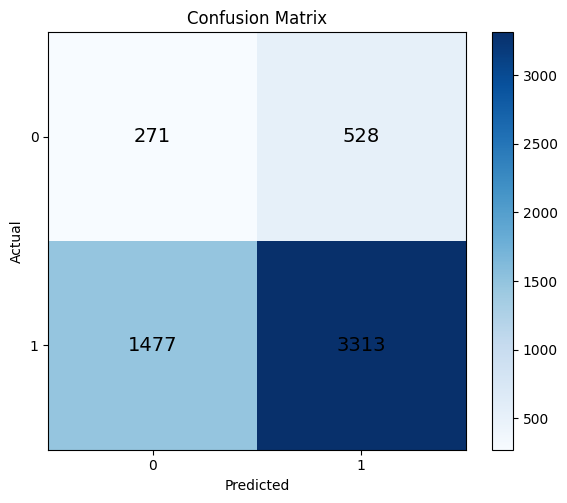

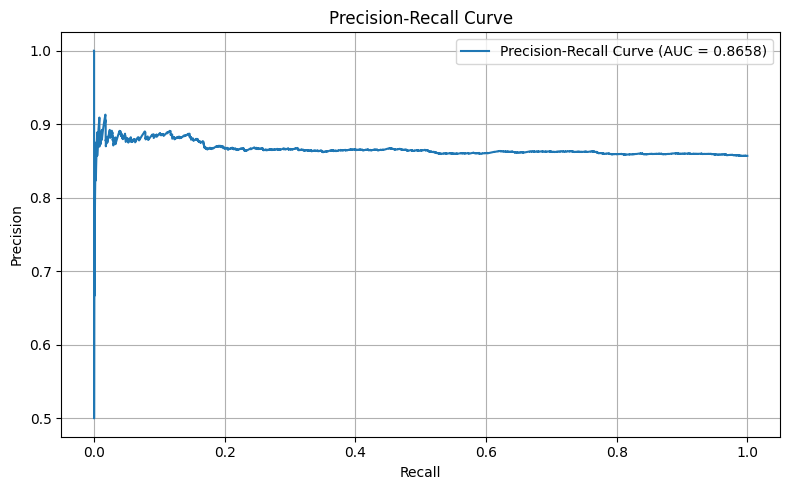

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier

# Preparing data
X_train = x_train_resampled.values if hasattr(x_train_resampled, 'values') else x_train_resampled
X_test = x_test.values if hasattr(x_test, 'values') else x_test
y_train = y_train_resampled.values.ravel() if hasattr(y_train_resampled, 'values') else y_train_resampled
y_test = y_test.values.ravel() if hasattr(y_test, 'values') else y_test

# Initialize and train TabNetClassifier with best hyperparameters
model = TabNetClassifier(
    n_d=64,
    n_a=42,
    n_steps=4,
    gamma=1.3125382645457688,
    lambda_sparse=6.829681514493817e-05,
    optimizer_params=dict(lr=0.006461292681283383),
    mask_type='entmax'
)

model.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['auc'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,

)


y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, y_pred_train)
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score_val = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
sen = recall_final
spe = tn / (tn + fp)
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)


precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)


print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score_val:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")


plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 10 Fold Cross Validation

In [ ]:

class TabNetWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.model = TabNetClassifier(**kwargs)

    def fit(self, X, y):
        X = X.values if hasattr(X, 'values') else X
        y = y.values if hasattr(y, 'values') else y
        self.model.fit(X, y)
        return self

    def predict(self, X):
        X = X.values if hasattr(X, 'values') else X
        return self.model.predict(X)

    def predict_proba(self, X):
        X = X.values if hasattr(X, 'values') else X
        return self.model.predict_proba(X)

# Custom PR AUC scorer
def pr_auc_score_func(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    precision, recall, _ = precision_recall_curve(y, y_prob)
    return auc(recall, precision)

# Custom Balanced Error Rate scorer
def balanced_error_rate_func(estimator, X, y):
    y_pred = estimator.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return 1 - 0.5 * (sensitivity + specificity)

#  TabNet model with provided parameters
tabnet_model = TabNetWrapper(
    n_d=64,
    n_a=42,
    n_steps=4,
    gamma=1.3125382645457688,
    lambda_sparse=6.829681514493817e-05,
    optimizer_params=dict(lr=0.006461292681283383),
    mask_type='entmax',
    verbose=0,
    seed=42
)

#  SMOTE + TabNet pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', tabnet_model)
])

#  Scoring dictionary
scoring = {
    'accuracy': lambda est, X, y: accuracy_score(y, est.predict(X)),
    'precision': lambda est, X, y: precision_score(y, est.predict(X)),
    'recall': lambda est, X, y: recall_score(y, est.predict(X)),
    'f1': lambda est, X, y: f1_score(y, est.predict(X)),
    'roc_auc': lambda est, X, y: roc_auc_score(y, est.predict_proba(X)[:, 1]),
    'pr_auc': pr_auc_score_func,
    'ber': balanced_error_rate_func
}

# 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring)

#  Print results
print("\n📊 10-Fold CV Results with SMOTE (TabNet):")
for key in scores:
    if key.startswith('test_'):
        metric = key.replace('test_', '')
        values = scores[key]
        print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")


/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")
/usr/local/lib/python3.11/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.70604 |  0:00:03s
epoch 1  | loss: 0.65328 |  0:00:05s
epoch 2  | loss: 0.62916 |  0:00:07s
epoch 3  | loss: 0.61053 |  0:00:09s
epoch 4  | loss: 0.59547 |  0:00:11s
epoch 5  | loss: 0.58918 |  0:00:12s
epoch 6  | loss: 0.58374 |  0:00:14s
epoch 7  | loss: 0.58179 |  0:00:15s
epoch 8  | loss: 0.57941 |  0:00:17s
epoch 9  | loss: 0.57549 |  0:00:19s
epoch 10 | loss: 0.57422 |  0:00:21s
epoch 11 | loss: 0.5742  |  0:00:23s
epoch 12 | loss: 0.57295 |  0:00:24s
epoch 13 | loss: 0.57249 |  0:00:26s
epoch 14 | loss: 0.56973 |  0:00:28s
epoch 15 | loss: 0.56797 |  0:00:29s
epoch 16 | loss: 0.56952 |  0:00:31s
epoch 17 | loss: 0.56643 |  0:00:33s
epoch 18 | loss: 0.56446 |  0:00:35s
epoch 19 | loss: 0.56321 |  0:00:37s
epoch 20 | loss: 0.56147 |  0:00:38s
epoch 21 | loss: 0.55809 |  0:00:40s
epoch 22 | loss: 0.5606  |  0:00:42s
epoch 23 | loss: 0.55787 |  0:00:44s
epoch 24 | loss: 0.55758 |  0:00:46s
epoch 25 | loss: 0.5564  |  0:00:47s
epoch 26 | loss: 0.55314 |  0:00:49s
e

/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline 

epoch 0  | loss: 0.70752 |  0:00:01s
epoch 1  | loss: 0.65224 |  0:00:03s
epoch 2  | loss: 0.63244 |  0:00:05s
epoch 3  | loss: 0.61295 |  0:00:07s
epoch 4  | loss: 0.59469 |  0:00:09s
epoch 5  | loss: 0.58645 |  0:00:11s
epoch 6  | loss: 0.58086 |  0:00:12s
epoch 7  | loss: 0.58063 |  0:00:14s
epoch 8  | loss: 0.5781  |  0:00:16s
epoch 9  | loss: 0.57558 |  0:00:17s
epoch 10 | loss: 0.5721  |  0:00:19s
epoch 11 | loss: 0.57367 |  0:00:22s
epoch 12 | loss: 0.57081 |  0:00:23s
epoch 13 | loss: 0.57083 |  0:00:25s
epoch 14 | loss: 0.56852 |  0:00:27s
epoch 15 | loss: 0.56847 |  0:00:28s
epoch 16 | loss: 0.5649  |  0:00:30s
epoch 17 | loss: 0.56416 |  0:00:32s
epoch 18 | loss: 0.56354 |  0:00:34s
epoch 19 | loss: 0.56349 |  0:00:36s
epoch 20 | loss: 0.5622  |  0:00:37s
epoch 21 | loss: 0.56197 |  0:00:39s
epoch 22 | loss: 0.56269 |  0:00:41s
epoch 23 | loss: 0.55952 |  0:00:43s
epoch 24 | loss: 0.55824 |  0:00:45s
epoch 25 | loss: 0.55857 |  0:00:47s
epoch 26 | loss: 0.55695 |  0:00:48s
e

/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline 

...

/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline 

epoch 0  | loss: 0.70997 |  0:00:01s
epoch 1  | loss: 0.65017 |  0:00:03s
epoch 2  | loss: 0.63014 |  0:00:05s
epoch 3  | loss: 0.61852 |  0:00:06s
epoch 4  | loss: 0.60785 |  0:00:08s
epoch 5  | loss: 0.59915 |  0:00:10s
epoch 6  | loss: 0.59297 |  0:00:12s
epoch 7  | loss: 0.58711 |  0:00:14s
epoch 8  | loss: 0.58347 |  0:00:15s
epoch 9  | loss: 0.58028 |  0:00:17s
epoch 10 | loss: 0.57685 |  0:00:19s
epoch 11 | loss: 0.5759  |  0:00:20s
epoch 12 | loss: 0.5756  |  0:00:23s
epoch 13 | loss: 0.57557 |  0:00:24s
epoch 14 | loss: 0.5727  |  0:00:26s
epoch 15 | loss: 0.5708  |  0:00:27s
epoch 16 | loss: 0.57053 |  0:00:29s
epoch 17 | loss: 0.5684  |  0:00:31s
epoch 18 | loss: 0.56588 |  0:00:33s
epoch 19 | loss: 0.56579 |  0:00:35s
epoch 20 | loss: 0.56546 |  0:00:36s
epoch 21 | loss: 0.56194 |  0:00:38s
epoch 22 | loss: 0.56064 |  0:00:40s
epoch 23 | loss: 0.55894 |  0:00:41s
epoch 24 | loss: 0.55788 |  0:00:43s
epoch 25 | loss: 0.55723 |  0:00:45s
epoch 26 | loss: 0.55786 |  0:00:47s
e

/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline 


📊 10-Fold CV Results with SMOTE (TabNet):
ACCURACY: 0.6462 ± 0.0106
PRECISION: 0.8474 ± 0.0016
RECALL: 0.7118 ± 0.0154
F1: 0.7736 ± 0.0090
ROC_AUC: 0.4889 ± 0.0086
PR_AUC: 0.8448 ± 0.0044
BER: 0.5066 ± 0.0046


/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


In [ ]:
pip install --upgrade rtdl

In [ ]:
pip install rtdl scikit-learn


Epoch 1, Training Loss: 24.0246, Validation Loss: 0.5714
Epoch 2, Training Loss: 22.5526, Validation Loss: 0.6525
Epoch 3, Training Loss: 22.1489, Validation Loss: 0.5931
Epoch 4, Training Loss: 21.9017, Validation Loss: 0.6751
Epoch 5, Training Loss: 21.4851, Validation Loss: 0.6872
Epoch 6, Training Loss: 21.2791, Validation Loss: 0.6692
Epoch 7, Training Loss: 21.1785, Validation Loss: 0.6454
Epoch 8, Training Loss: 21.0367, Validation Loss: 0.6418
Epoch 9, Training Loss: 21.0186, Validation Loss: 0.5975
Epoch 10, Training Loss: 20.6192, Validation Loss: 0.6660
Epoch 11, Training Loss: 20.6058, Validation Loss: 0.6336
Early stopping triggered.
Confusion Matrix:
 [[ 147  652]
 [ 858 3932]]
Training Accuracy: 0.6846
Test Accuracy: 0.7298
Sensitivity (Recall): 0.8209
Specificity: 0.1840
Balanced Error Rate: 0.4976
F1 Score: 0.8389
MCC: 0.0044
Kappa: 0.0044
ROC-AUC Score: 0.5025
Precision-Recall AUC: 0.8540


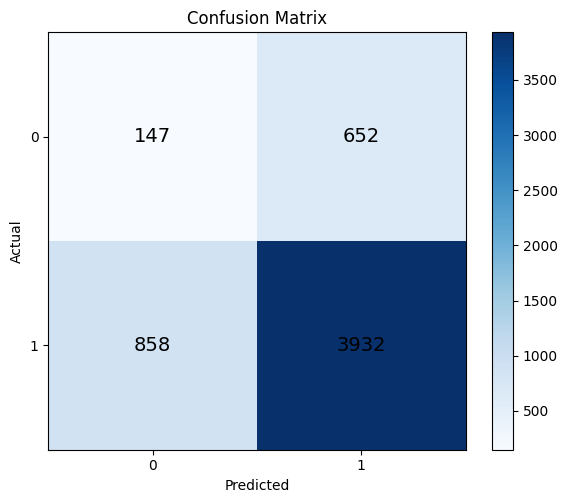

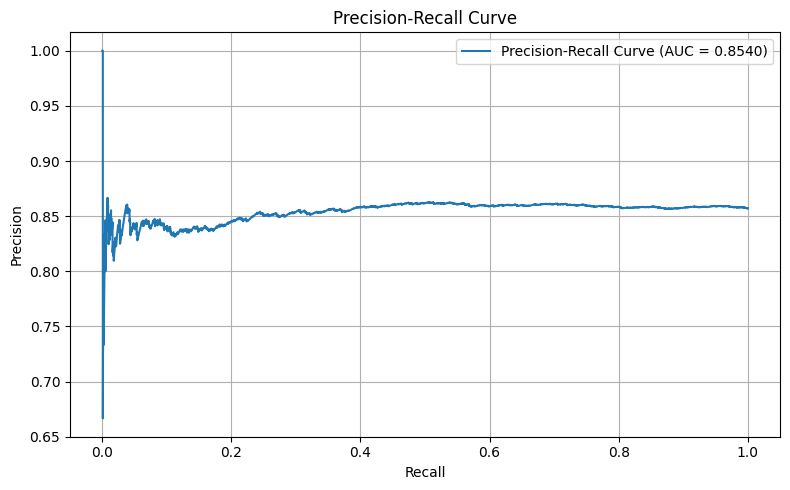

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

#  Prepare data
X_train = x_train_resampled.values if hasattr(x_train_resampled, 'values') else x_train_resampled
X_test = x_test.values if hasattr(x_test, 'values') else x_test
y_train = y_train_resampled.values.ravel() if hasattr(y_train_resampled, 'values') else y_train_resampled
y_test = y_test.values.ravel() if hasattr(y_test, 'values') else y_test

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 230),                 # hidden1
            nn.ReLU(),
            nn.Dropout(0.34688785084690066),           # dropout1
            nn.Linear(230, 43),                         # hidden2
            nn.ReLU(),
            nn.Dropout(0.31399977753902425),           # dropout2
            nn.Linear(43, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

model = MLP(input_dim=X_train.shape[1])

#  Training setup
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00695581978541054)
epochs = 100
batch_size = 1024
patience = 10
best_loss = float('inf')
patience_counter = 0

# Training loop with early stopping
for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train_tensor.size()[0])
    total_loss = 0

    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    #  Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor).item()

    print(f"Epoch {epoch+1}, Training Loss: {total_loss:.4f}, Validation Loss: {val_loss:.4f}")

    #  Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_mlp_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

#  Load best model
model.load_state_dict(torch.load("best_mlp_model.pth"))
model.eval()

# Predictions
with torch.no_grad():
    y_prob = model(X_test_tensor).numpy().flatten()
    y_pred = (y_prob > 0.5).astype(int)
    y_pred_train = (model(X_train_tensor).numpy().flatten() > 0.5).astype(int)

#  Metrics
train_accuracy = accuracy_score(y_train, y_pred_train)
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()
auc_score_val = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
sen = recall_final
spe = tn / (tn + fp)
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

#  Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print metrics
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score_val:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 10 Fold Cross Validation

In [ ]:

x = x.values if hasattr(x, 'values') else x
y = y.values if hasattr(y, 'values') else y

# Defineing MLP model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 230),
            nn.ReLU(),
            nn.Dropout(0.34688785084690066),
            nn.Linear(230, 43),
            nn.ReLU(),
            nn.Dropout(0.31399977753902425),
            nn.Linear(43, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# Evaluation function
def evaluate(model, X_val, y_val):
    model.eval()
    with torch.no_grad():
        y_prob = model(torch.tensor(X_val).float()).numpy().flatten()
        y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    return {
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred),
        'roc_auc': roc_auc_score(y_val, y_prob),
        'pr_auc': auc(recall, precision),
        'ber': 1 - 0.5 * (sensitivity + specificity)
    }

# 10-fold cross-validation with SMOTE
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_list = []

for train_idx, val_idx in cv.split(x, y):
    X_train, y_train = x[train_idx], y[train_idx]
    X_val, y_val = x[val_idx], y[val_idx]

    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)

    train_dataset = TensorDataset(torch.tensor(X_res).float(), torch.tensor(y_res).float().unsqueeze(1))
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

    model = MLP(input_dim=x.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.00695581978541054)

    best_loss = float('inf')
    patience = 10
    patience_counter = 0

    for epoch in range(100):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            val_preds = model(torch.tensor(X_val).float()).numpy().flatten()
            val_loss = criterion(torch.tensor(val_preds), torch.tensor(y_val).float()).item()

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    fold_metrics = evaluate(model, X_val, y_val)
    metrics_list.append(fold_metrics)

# Print averaged results
print("\n📊 10-Fold CV Results with SMOTE (MLP):")
for metric in metrics_list[0]:
    values = [m[metric] for m in metrics_list]
    print(f"{metric.upper()}: {np.mean(values):.4f} ± {np.std(values):.4f}")



📊 10-Fold CV Results with SMOTE (MLP):
ACCURACY: 0.7415 ± 0.0223
PRECISION: 0.8491 ± 0.0017
RECALL: 0.8461 ± 0.0324
F1: 0.8473 ± 0.0162
ROC_AUC: 0.4996 ± 0.0124
PR_AUC: 0.8505 ± 0.0052
BER: 0.5022 ± 0.0058


# Ensemble Learning

## With Stackng

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:21:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Info] Number of positive: 18957, number of negative: 18957
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 37914, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:24:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:24:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:24:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:24:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:24:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Info] Number of positive: 15166, number of negative: 15165
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 30331, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500016 -> initscore=0.000066
[LightGB

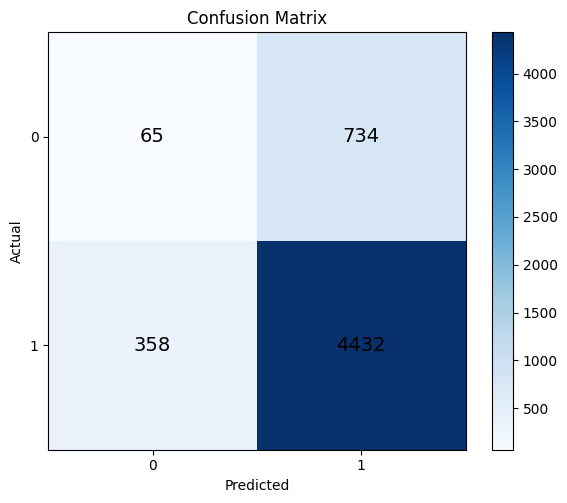

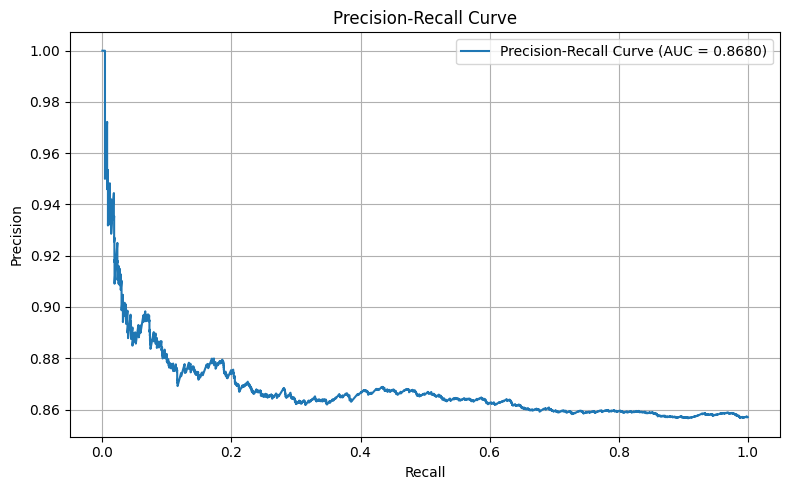

In [ ]:
from sklearn.ensemble import StackingClassifier

gb_params = {
    'n_estimators': 250,
    'learning_rate': 0.1,
    'max_depth': 7,
    'subsample': 1.0,
    'min_samples_split': 7
}
gb_tuned = GradientBoostingClassifier(**gb_params)


xgb_params = {
    'n_estimators': 200,
    'max_depth': 7,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'use_label_encoder': False,
    'eval_metric': 'logloss'
}

xgb_tuned = XGBClassifier(**xgb_params)


lgm_params = {
    'n_estimators': 200,
    'learning_rate': 0.15,
    'max_depth': 7,
    'min_child_samples': 7,
    'max_bin': 100,
    'feature_fraction': 0.7,
    'min_data_in_leaf': 20
}

lgm_tuned = LGBMClassifier(**lgm_params)

gnb_params = {
    'var_smoothing': 1e-06
}
gnb_tuned = GaussianNB(**gnb_params)

rf_params = {
    'n_estimators': 50,
    'max_depth': 10,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'random_state': 42
}
rf_tuned = RandomForestClassifier(**rf_params)


knn_tuned= KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='uniform')

svc_tuned = SVC(C=10, kernel='rbf', gamma=0.01, class_weight='balanced', probability=False)

base_models = [
    ('rf', rf_tuned),        # RandomForestClassifier
    ('xgb', xgb_tuned),      # XGBClassifier
    ('gb', gb_tuned),        # GradientBoostingClassifier
    ('gnb', gnb_tuned),      # Gaussian Naive Bayes
    ('knn', knn_tuned),      # KNeighborsClassifier
    ('svc', svc_tuned),      # SVC
    ('lgm', lgm_tuned)       # LightGBM (pre-tuned)
]

#  meta-model
meta_model = LogisticRegression()


stacking_model = StackingClassifier(
    estimators=base_models,   # List of base models
    final_estimator=meta_model  # Meta-model
)

# Train the StackingClassifier
stacking_model.fit(x_train_resampled, y_train_resampled)

# Make predictions
y_pred = stacking_model.predict(x_test)
y_prob = stacking_model.predict_proba(x_test)[:, 1]  # for AUC calculation
y_train_pred = stacking_model.predict(x_train_resampled)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# AUC, Precision-Recall AUC
auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final
spe = tn / (tn + fp)
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print the results
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Confusion Matrix plot
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Precision-Recall Curve plot
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10 Fold cross validation for Stacking

In [ ]:

x = x.values if hasattr(x, 'values') else x
y = y.values if hasattr(y, 'values') else y

# Definng base models and meta-model
gb_tuned = GradientBoostingClassifier(n_estimators=250, learning_rate=0.1, max_depth=7, subsample=1.0, min_samples_split=7)
xgb_tuned = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, gamma=0.1, use_label_encoder=False, eval_metric='logloss')
lgm_tuned = LGBMClassifier(n_estimators=200, learning_rate=0.15, max_depth=7, min_child_samples=7, max_bin=100, feature_fraction=0.7, min_data_in_leaf=20)
gnb_tuned = GaussianNB(var_smoothing=1e-06)
rf_tuned = RandomForestClassifier(n_estimators=50, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
knn_tuned = KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='uniform')
svc_tuned = SVC(C=10, kernel='rbf', gamma=0.01, class_weight='balanced', probability=True)

# Definining base models
base_models = [
    ('rf', rf_tuned),
    ('xgb', xgb_tuned),
    ('gb', gb_tuned),
    ('gnb', gnb_tuned),
    ('knn', knn_tuned),
    ('svc', svc_tuned),
    ('lgm', lgm_tuned)
]

# Define stacking model
meta_model = LogisticRegression()
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

# Creating pipeline with SMOTE to avoid any kind of possible leakage
pipeline =Pipeline([
    ('smote',SMOTE(random_state=42)),
    ('stacking',stacking_model)
])

# Cross-validation part
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_list = []

for fold, (train_idx, test_idx) in enumerate(cv.split(x, y), 1):
    X_train, y_train = x[train_idx], y[train_idx]
    X_test, y_test = x[test_idx], y[test_idx]


    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    conf_matrix = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    sen = recall_score(y_test, y_pred)
    spe = tn / (tn + fp)
    ber = 1 - 0.5 * (sen + spe)
    pr, rc, _ = precision_recall_curve(y_test, y_prob)
    metrics_list.append({
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': sen,
        'specificity': spe,
        'ber': ber,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(rc, pr)
    })

print("\n 10-Fold Cross-Validation Metrics with Stacking:")
for metric in metrics_list[0]:
    scores = [m[metric] for m in metrics_list]
    print(f"{metric.upper()}:{np.mean(scores):.4f} ± {np.std(scores):.4f}")


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Info] Number of positive: 21372, number of negative: 21372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2800
[LightGBM] [Info] Number of data points in the train set: 42744, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightG

## With Voting

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:30:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=7 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Info] Number of positive: 18957, number of negative: 18957
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 552
[LightGBM] [Info] Number of data points in the train set: 37914, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGB

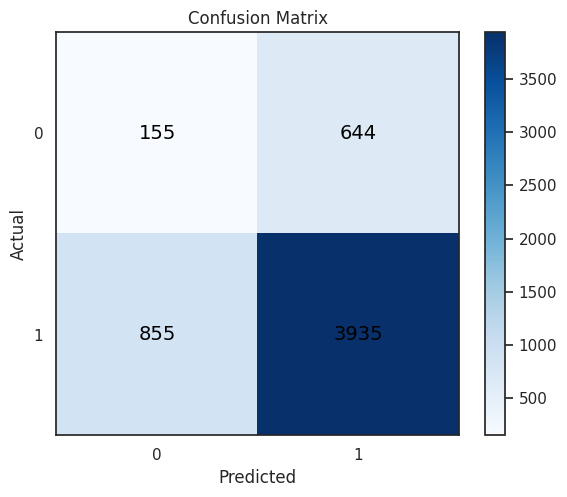

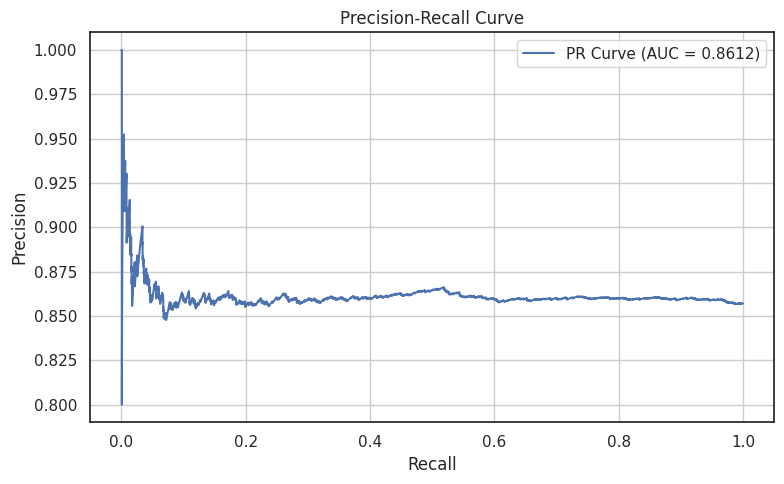

In [ ]:
from sklearn.ensemble import VotingClassifier


# Defining base classifiers with tuned hyperparameters
gb_params = {
    'n_estimators': 250, 'learning_rate': 0.1,
    'max_depth': 7, 'subsample': 1.0,
    'min_samples_split': 7
}
gb_tuned = GradientBoostingClassifier(**gb_params)

xgb_params = {
    'n_estimators': 200, 'max_depth': 7,
    'learning_rate': 0.1, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'gamma': 0.1,
    'use_label_encoder': False, 'eval_metric': 'logloss'
}
xgb_tuned = XGBClassifier(**xgb_params)

lgm_params = {
    'n_estimators': 200, 'learning_rate': 0.15,
    'max_depth': 7, 'min_child_samples': 7,
    'max_bin': 100, 'feature_fraction': 0.7,
    'min_data_in_leaf': 20
}
lgm_tuned = LGBMClassifier(**lgm_params)

gnb_tuned = GaussianNB(var_smoothing=1e-06)

rf_params = {
    'n_estimators': 50, 'max_depth': 10,
    'min_samples_split': 10, 'min_samples_leaf': 5,
    'random_state': 42
}
rf_tuned = RandomForestClassifier(**rf_params)

knn_tuned = KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='uniform')

svc_tuned = SVC(C=10, kernel='rbf', gamma=0.01, class_weight='balanced', probability=True)

# Base classifiers
base_models = [
    ('rf', rf_tuned),
    ('xgb', xgb_tuned),
    ('gb', gb_tuned),
    ('gnb', gnb_tuned),
    ('knn', knn_tuned),
    ('svc', svc_tuned),
    ('lgm', lgm_tuned)
]

voting_model = VotingClassifier(
    estimators=base_models,
    voting='soft'  # using 'soft' to average predicted probabilities
)

# Train the VotingClassifier
voting_model.fit(x_train_resampled, y_train_resampled)

# Predictions
y_pred = voting_model.predict(x_test)
y_prob = voting_model.predict_proba(x_test)[:, 1]
y_train_pred = voting_model.predict(x_train_resampled)

# Evaluation Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

auc_score = roc_auc_score(y_test, y_prob)
precision_final = precision_score(y_test, y_pred)
recall_final = recall_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred)
train_acc = accuracy_score(y_train_resampled, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
sen = recall_final
spe = tn / (tn + fp)
ber = 1 - 0.5 * (sen + spe)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

# Print Results
print("Confusion Matrix:\n", conf_matrix)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Sensitivity (Recall): {sen:.4f}")
print(f"Specificity: {spe:.4f}")
print(f"Balanced Error Rate: {ber:.4f}")
print(f"F1 Score: {f1_final:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=14)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()
plt.tight_layout()
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Testing Shap Graph for Explainable AI

 99%|===================| 5535/5589 [00:55<00:00]       

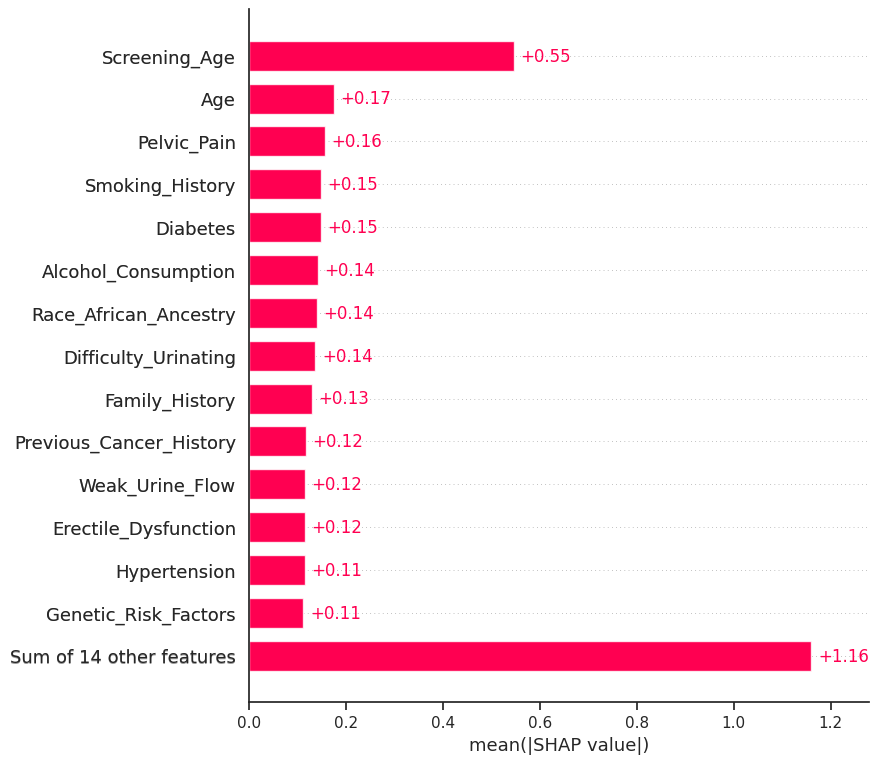

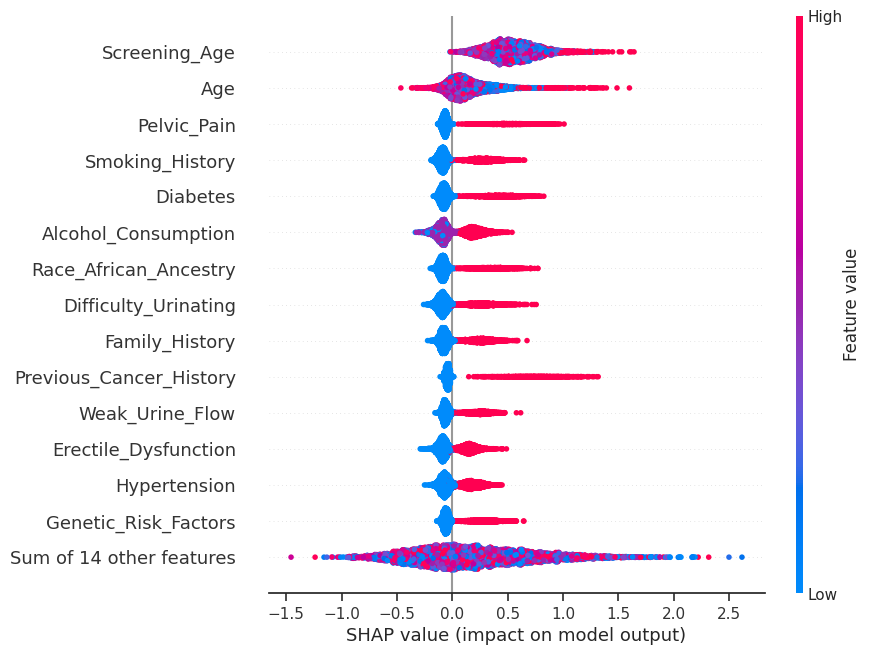

100%|===================| 11163/11178 [01:43<00:00]       

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.218205, while the model output was 0.205182. If this difference is acceptable you can set check_additivity=False to disable this check.

In [ ]:
import shap

xgb_model = voting_model.named_estimators_['xgb']

explainer = shap.Explainer(xgb_model, x_train_resampled)

shap_values = explainer(x_test)

shap.plots.bar(shap_values, max_display=15)

# Beeswarm plot for distribution of SHAP values across samples
shap.plots.beeswarm(shap_values, max_display=15)



rf_model = voting_model.named_estimators_['rf']

explainer_rf = shap.Explainer(rf_model, x_train_resampled)
shap_values_rf = explainer_rf(x_test)

# Plots
shap.plots.bar(shap_values_rf, max_display=15)
shap.plots.beeswarm(shap_values_rf, max_display=15)




lgb_model = voting_model.named_estimators_['lgm']

explainer_lgb = shap.Explainer(lgb_model, x_train_resampled)
shap_values_lgb = explainer_lgb(x_test)

# Plots
shap.plots.bar(shap_values_lgb, max_display=15)
shap.plots.beeswarm(shap_values_lgb, max_display=15)



gb_model = voting_model.named_estimators_['gb']

explainer_gb = shap.Explainer(gb_model, x_train_resampled)
shap_values_gb = explainer_gb(x_test)

# Plots
shap.plots.bar(shap_values_gb, max_display=15)
shap.plots.beeswarm(shap_values_gb, max_display=15)
